# Manufacturing Process Optimization & Predictive Quality Analytics

## Notebook 01
### Data Quality Audit

Objective:
Perform an initial audit of the manufacturing dataset to understand its structure, completeness, and readiness for further analysis.


In [1]:
import pandas as pd
import numpy as np

In [ ]:
file_path = r"D:\Projects\SQL\Manufacturing Process Optimization & Predictive Quality Analytics\data\raw\continuous_factory_process.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 14088
Columns : 116


## Business Observation

The dataset contains **14,088 production records** collected across **116 manufacturing variables**.

This indicates that the organization has implemented a comprehensive manufacturing data collection framework covering environmental conditions, raw material properties, machine operating parameters, and quality inspection measurements across multiple production stages.

The dataset size is sufficient for descriptive analytics, statistical analysis, and predictive machine learning.

In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

## Observation

No missing values were found in the dataset.

This indicates strong sensor reliability and disciplined manufacturing data collection practices.

In [7]:
duplicates = df.duplicated().sum()

print(duplicates)

0


## Business Significance

Duplicate production records may indicate repeated sensor logging or duplicate manufacturing events.

Such records can bias statistical analysis and machine learning models if not identified.

We don't have any duplicate data in our dataset.

In [8]:
df.dtypes

time_stamp                                        object
AmbientConditions.AmbientHumidity.U.Actual       float64
AmbientConditions.AmbientTemperature.U.Actual    float64
Machine1.RawMaterial.Property1                   float64
Machine1.RawMaterial.Property2                     int64
                                                  ...   
Stage2.Output.Measurement12.U.Setpoint           float64
Stage2.Output.Measurement13.U.Actual             float64
Stage2.Output.Measurement13.U.Setpoint           float64
Stage2.Output.Measurement14.U.Actual             float64
Stage2.Output.Measurement14.U.Setpoint           float64
Length: 116, dtype: object

## Observation

The `time_stamp` column is currently stored as an object instead of a datetime datatype.

This must be converted before performing trend analysis, production shift analysis, daily production summaries, or time-series analytics.

# Manufacturing Variable Inventory

Before performing statistical or SQL analysis, it is important to understand how the manufacturing process is represented in the dataset.

The variables can be grouped into logical manufacturing stages instead of treating all 116 variables independently.

This improves process understanding, simplifies future SQL queries, and helps identify where quality variation originates.

In [2]:
variable_groups = {

"Ambient Conditions": [],

"Machine 1 Raw Material": [],

"Machine 1 Process": [],

"Machine 2 Raw Material": [],

"Machine 2 Process": [],

"Machine 3 Raw Material": [],

"Machine 3 Process": [],

"Combiner Stage": [],

"Stage 1 Quality": [],

"Machine 4 Process": [],

"Machine 5 Process": [],

"Stage 2 Quality": []

}

In [5]:
for col in df.columns:

    if "AmbientConditions" in col:
        variable_groups["Ambient Conditions"].append(col)

    elif "Machine1.RawMaterial" in col:
        variable_groups["Machine 1 Raw Material"].append(col)

    elif "Machine1." in col:
        variable_groups["Machine 1 Process"].append(col)

    elif "Machine2.RawMaterial" in col:
        variable_groups["Machine 2 Raw Material"].append(col)

    elif "Machine2." in col:
        variable_groups["Machine 2 Process"].append(col)

    elif "Machine3.RawMaterial" in col:
        variable_groups["Machine 3 Raw Material"].append(col)

    elif "Machine3." in col:
        variable_groups["Machine 3 Process"].append(col)

    elif "FirstStage.Combiner" in col:
        variable_groups["Combiner Stage"].append(col)

    elif "Stage1.Output" in col:
        variable_groups["Stage 1 Quality"].append(col)

    elif "Machine4." in col:
        variable_groups["Machine 4 Process"].append(col)

    elif "Machine5." in col:
        variable_groups["Machine 5 Process"].append(col)

    elif "Stage2.Output" in col:
        variable_groups["Stage 2 Quality"].append(col)

In [6]:
for group, columns in variable_groups.items():

    print("="*50)

    print(group)

    print("Variables :", len(columns))

    print("="*50)

Ambient Conditions
Variables : 2
Machine 1 Raw Material
Variables : 5
Machine 1 Process
Variables : 7
Machine 2 Raw Material
Variables : 5
Machine 2 Process
Variables : 7
Machine 3 Raw Material
Variables : 5
Machine 3 Process
Variables : 7
Combiner Stage
Variables : 3
Stage 1 Quality
Variables : 30
Machine 4 Process
Variables : 7
Machine 5 Process
Variables : 7
Stage 2 Quality
Variables : 30


## Business Interpretation

The dataset captures the complete manufacturing workflow.

It begins with environmental monitoring and raw material inspection before entering the first production stage consisting of three independent machines.

The outputs from these machines are combined and immediately inspected through Stage 1 quality measurements.

The semi-finished product then passes through Machines 4 and 5 before final quality inspection.

This structure confirms that quality variation can originate from multiple stages of manufacturing rather than a single machine.

# Manufacturing Process Summary

The dataset consists of multiple manufacturing stages, each contributing different types of variables.

This section summarizes how much information is collected from each stage and confirms that the entire manufacturing process is represented within the dataset.

In [7]:
summary = pd.DataFrame({
    "Manufacturing Stage": variable_groups.keys(),
    "Number of Variables": [len(cols) for cols in variable_groups.values()]
})

summary

,Manufacturing Stage,Number of Variables
0,Ambient Conditions,2
1,Machine 1 Raw Material,5
2,Machine 1 Process,7
3,Machine 2 Raw Material,5
4,Machine 2 Process,7
5,Machine 3 Raw Material,5
6,Machine 3 Process,7
7,Combiner Stage,3
8,Stage 1 Quality,30
9,Machine 4 Process,7


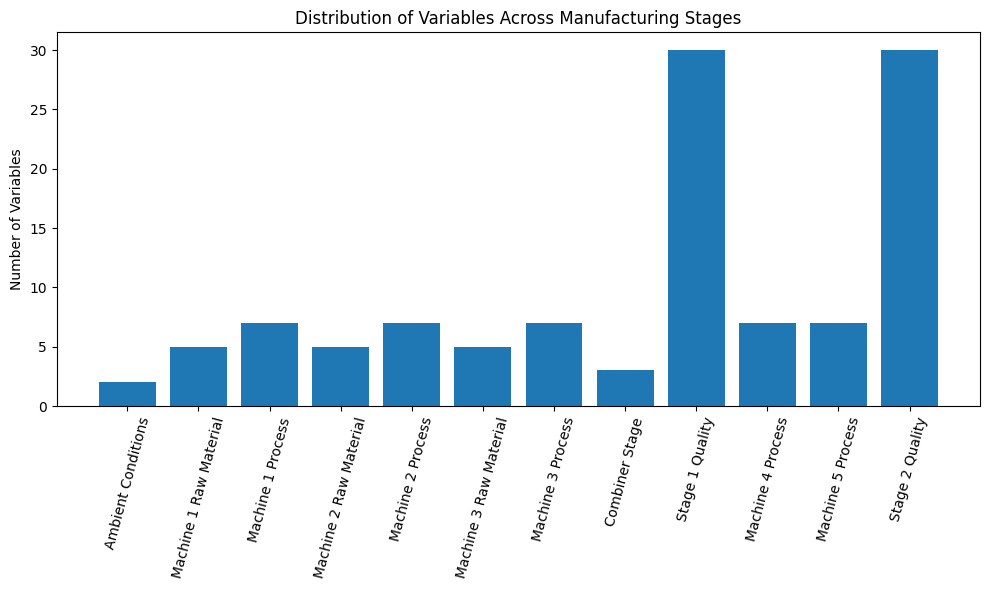

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(summary["Manufacturing Stage"],
        summary["Number of Variables"])

plt.xticks(rotation=75)

plt.ylabel("Number of Variables")

plt.title("Distribution of Variables Across Manufacturing Stages")

plt.tight_layout()

plt.show()

## Business Interpretation

The manufacturing process is comprehensively monitored across all production stages.

The highest concentration of variables belongs to the Stage 1 and Stage 2 quality measurements because multiple dimensional characteristics are inspected after each manufacturing stage.

Each production machine contributes its own raw material properties and operating parameters, enabling complete traceability from raw material input to final product quality.

In [ ]:
import csv
df.to_csv(
    r"D:\Projects\SQL\Manufacturing Process Optimization & Predictive Quality Analytics\data\processed\manufacturing_process_clean.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print("SQL-friendly CSV created successfully.")

SQL-friendly CSV created successfully.


In [11]:
from sqlalchemy import create_engine

engine = create_engine(
    "mssql+pyodbc://localhost/Manufacturing_Process_Optimization?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

df.head(0).to_sql(
    "manufacturing_process_optimization",
    engine,
    if_exists="replace",
    index=False
)

ModuleNotFoundError: No module named 'sqlalchemy'